In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [32]:
data = pd.read_csv('/content/retail_cleans.csv')

In [33]:
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,MonthYear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,dic,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,dic,2009-12-01
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,dic,2009-12-01
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,dic,2009-12-01


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400916 non-null  int64  
 1   StockCode    400916 non-null  object 
 2   Description  400916 non-null  object 
 3   Quantity     400916 non-null  int64  
 4   InvoiceDate  400916 non-null  object 
 5   Price        400916 non-null  float64
 6   Customer ID  400916 non-null  int64  
 7   Country      400916 non-null  object 
 8   TotalPrice   400916 non-null  float64
 9   Year         400916 non-null  int64  
 10  Month        400916 non-null  object 
 11  MonthYear    400916 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 36.7+ MB


In [35]:
data = data.dropna(subset=['Price', 'Quantity'])

In [36]:
# remove invalid values
data = data[(data['Quantity'] > 0) & (data['Price'] > 0)]

In [37]:
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

data = data[(data['Price'] >= Q1 - 1.5*IQR) &
            (data['Price'] <= Q3 + 1.5*IQR)]

In [38]:
Q1 = data['Quantity'].quantile(0.25)
Q3 = data['Quantity'].quantile(0.75)
IQR = Q3 - Q1

data = data[(data['Quantity'] >= Q1 - 1.5*IQR) &
            (data['Quantity'] <= Q3 + 1.5*IQR)]

In [39]:
X = data[['Price', 'Quantity']].values

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

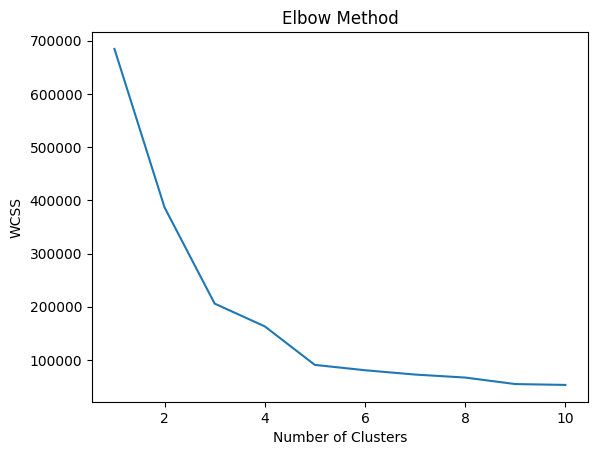

In [41]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [42]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=0)
Y = kmeans.fit_predict(X_scaled)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


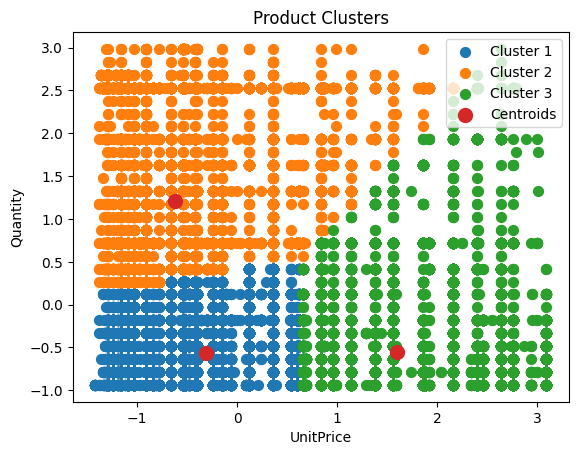

In [43]:
plt.figure()

plt.scatter(X_scaled[Y == 0, 0], X_scaled[Y == 0, 1], s=50, label='Cluster 1')
plt.scatter(X_scaled[Y == 1, 0], X_scaled[Y == 1, 1], s=50, label='Cluster 2')
plt.scatter(X_scaled[Y == 2, 0], X_scaled[Y == 2, 1], s=50, label='Cluster 3')

# centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=100, label='Centroids')

plt.xlabel('UnitPrice')
plt.ylabel('Quantity')
plt.title('Product Clusters')
plt.legend()
plt.show()